# Smart Mobility Analisis

**Curso III -- Diana Carolina Leguizamon**

## 0. Preparacion del entorno

Importar las librerias que se van a usar a lo largo de todo el notebook. 

In [6]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install numpy pandas matplotlib seaborn scikit-learn xgboost

Note: you may need to restart the kernel to use updated packages.


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Los datos: Smart Mobility Dataset

Vamos a usar un dataset llamado Smart Mobility Dataset. 
Fuente: https://www.kaggle.com/datasets/ziya07/smart-mobility-traffic-dataset?select=smart_mobility_dataset.csv 

• ¿Qué quieres analizar y por qué es interesante? 
Predicción de condiciones de tráfico urbano mediante machine learning
¿Qué factores permiten predecir las condiciones del tráfico urbano?
• ¿Qué enfoque elegiste (predicción, clustering o reducción de dimensionalidad)? 
Predicción

Este dataset tiene 15 columnas, 11 variables predictoras y 5000 observaciones.

In [9]:
df = pd.read_csv(r"C:\Users\dcleg\OneDrive\Documents\Repositorios\prueba_clase\Smart_Mobility_Traffic_DCLR\smart_mobility_dataset.csv")

In [10]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               5000 non-null   str    
 1   Latitude                5000 non-null   float64
 2   Longitude               5000 non-null   float64
 3   Vehicle_Count           5000 non-null   int64  
 4   Traffic_Speed_kmh       5000 non-null   float64
 5   Road_Occupancy_%        5000 non-null   float64
 6   Traffic_Light_State     5000 non-null   str    
 7   Weather_Condition       5000 non-null   str    
 8   Accident_Report         5000 non-null   int64  
 9   Sentiment_Score         5000 non-null   float64
 10  Ride_Sharing_Demand     5000 non-null   int64  
 11  Parking_Availability    5000 non-null   int64  
 12  Emission_Levels_g_km    5000 non-null   float64
 13  Energy_Consumption_L_h  5000 non-null   float64
 14  Traffic_Condition       5000 non-null   str    
dty

In [11]:
df.shape

(5000, 15)

In [12]:
df.head(5)

,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Traffic_Condition
0,2024-03-01 00:00:00,40.842275,-73.703149,205,49.893435,82.652780,Yellow,Clear,0,-0.609199,2,45,450.760055,19.574337,High
1,2024-03-01 00:05:00,40.831119,-73.987354,202,22.383965,45.829298,Green,Clear,0,0.965442,16,1,321.800341,5.385554,High
2,2024-03-01 00:10:00,40.819549,-73.732462,252,46.889699,82.772465,Green,Rain,0,0.289660,16,49,231.152655,10.277477,High
3,2024-03-01 00:15:00,40.725849,-73.980134,37,5.730536,37.695567,Red,Fog,0,-0.271965,66,10,410.384292,29.243279,High
4,2024-03-01 00:20:00,40.813265,-73.961631,64,61.348034,22.313358,Red,Snow,0,-0.797606,3,5,364.466342,16.801459,Low


Las variables son:

•	Timestamp | Marca de tiempo en la cual fue tomada la observación.             
•	Latitude | Latitud del punto donde se tomó la observación.              
•	Longitude | Longitud del punto donde se tomó la observación.              
•	Vehicle_Count | Numero de autos observados en el tiempo determinado.                
•	Traffic_Speed_kmh | Velocidad del trafico en el tiempo determinado.              
•	Road_Occupancy_% | Porcentaje de ocupación de la via.              
•	Traffic_Light_State | Color mostrado por el semaforo.              
•	Weather_Condition | Condición climatica.              
•	Accident_Report | Reporte de accidentes.              
•	Sentiment_Score | Comentarios del público en las redes sociales sobre el tráfico y la movilidad.             
•	Ride_Sharing_Demand | Demanda de transporte compartido.                 
•	Parking_Availability | Disponibilidad de parqueo.              
•	Emission_Levels_g_km | emisiones de CO₂ y niveles de contaminación.             
•	Energy_Consumption_L_h | Consumo de energia.              
•	Traffic_Condition | Nivel de congestión del tráfico (bajo, medio, alto) -> Variable a predecir.              


In [13]:
print(df["Traffic_Condition"].unique())

<ArrowStringArray>
['High', 'Low', 'Medium']
Length: 3, dtype: str


In [14]:

df["Traffic_Condition"] = df["Traffic_Condition"].map({"Low": 0, "Medium": 1, "High": 2})
df.head(2)



,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Traffic_Condition
0,2024-03-01 00:00:00,40.842275,-73.703149,205,49.893435,82.652780,Yellow,Clear,0,-0.609199,2,45,450.760055,19.574337,2
1,2024-03-01 00:05:00,40.831119,-73.987354,202,22.383965,45.829298,Green,Clear,0,0.965442,16,1,321.800341,5.385554,2


In [15]:
df.drop("Timestamp", axis=1, inplace=True)

In [16]:
df = pd.get_dummies(df, drop_first=False)

In [17]:
X = df.drop(columns = "Traffic_Condition")
y = df["Traffic_Condition"]

In [18]:
X

,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Traffic_Light_State_Green,Traffic_Light_State_Red,Traffic_Light_State_Yellow,Weather_Condition_Clear,Weather_Condition_Fog,Weather_Condition_Rain,Weather_Condition_Snow
0,40.842275,-73.703149,205,49.893435,82.652780,0,-0.609199,2,45,450.760055,19.574337,False,False,True,True,False,False,False
1,40.831119,-73.987354,202,22.383965,45.829298,0,0.965442,16,1,321.800341,5.385554,True,False,False,True,False,False,False
2,40.819549,-73.732462,252,46.889699,82.772465,0,0.289660,16,49,231.152655,10.277477,True,False,False,False,False,True,False
3,40.725849,-73.980134,37,5.730536,37.695567,0,-0.271965,66,10,410.384292,29.243279,False,True,False,False,True,False,False
4,40.813265,-73.961631,64,61.348034,22.313358,0,-0.797606,3,5,364.466342,16.801459,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,40.604663,-73.831032,266,22.987611,12.670629,0,0.698929,87,28,252.070807,7.511153,True,False,False,False,False,True,False
4996,40.733790,-73.752213,20,75.736987,49.108556,0,0.742800,5,0,203.563872,6.681980,True,False,False,False,False,False,True
4997,40.821354,-73.759376,43,59.492981,78.719110,0,0.524574,94,16,71.660296,25.267246,False,False,True,True,False,False,False
4998,40.772343,-73.836698,88,25.901119,64.690719,0,-0.589902,73,5,442.692618,29.467326,False,False,True,False,False,True,False


## 2. Division de datos: entrenamiento y prueba

Antes de hacer cualquier cosa, separamos los datos en dos conjuntos:
- **Entrenamiento (80%)**: con estos datos el modelo aprende.
- **Prueba (20%)**: con estos datos evaluamos que tan bien generaliza el modelo a datos que nunca ha visto.

Esto es fundamental para detectar si un modelo esta memorizando en lugar de aprendiendo (overfitting).

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((4000, 18), (1000, 18))

## 3. Modelo base: Regresion Lineal Clasica (OLS) --> Regresión lineal NO es el modelo ideal.

Porque la regresión lineal está diseñada para:

*variables continuas,
*no categorías.

Sin embargo empezamos con el modelo que ya conocemos. Esto nos da un punto de referencia contra el cual comparar todos los demas modelos.

La regresion lineal clasica (OLS = Ordinary Least Squares) busca los coeficientes que minimizan la suma de los errores al cuadrado, sin ningun tipo de restriccion adicional.

In [20]:
from sklearn.linear_model import LinearRegression

In [33]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

pd.DataFrame({
    "Metrica": ["MAE", "RMSE", "R2"],
    "Valor": [round(mae_lr, 4), round(rmse_lr, 4), round(r2_lr, 4)]
})

,Metrica,Valor
0,MAE,0.3663
1,RMSE,0.4475
2,R2,0.4508


Estos numeros son nuestro punto de partida. Cualquier modelo nuevo que probemos deberia intentar mejorar estas metricas:

- **MAE (Mean Absolute Error)**: en promedio, el modelo se equivoca en promedio 0,37 unidades respecto al valor real. 
- **RMSE (Root Mean Squared Error)**: similar al MAE pero penaliza mas los errores grandes. El error tipico es aproximadamente 0,45 unidades. RMSE>MAE significa que existen algunos errores mas grandes, pero no exageradamente grandes. 
- **R2**: el modelo explica aproximadamente 45,08% de la variabilidad de las condiciones de trafico. 
---

#💡Lo correcto es usar:
Modelos de clasificación

Por ejemplo:

-Logistic Regression
-Decision Tree
-Random Forest Classifier
-XGBoost Classifier

## 4. Logistic Regresion

In [45]:
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score, roc_curve
)

In [46]:
from sklearn.linear_model import LogisticRegression

In [47]:
# ─── Entrenar modelo ───
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)

log_reg = LogisticRegression()
log_reg.fit(X_tr, y_tr)

y_pred_log = log_reg.predict(X_te)
y_prob_log = log_reg.predict_proba(X_te)

In [48]:
y_pred_log

array([1, 2, 0, ..., 1, 2, 2], shape=(1500,))

In [49]:
cm = confusion_matrix(y_te, y_pred_log)
cm

array([[ 56,  38,   0],
       [ 23, 222, 194],
       [ 10, 135, 822]])

Interpretación por clases

Supongamos:

0 = tráfico bajo
1 = tráfico medio
2 = tráfico alto


Fila: [56, 38, 0]

Significa:

56 casos fueron correctamente clasificados como tráfico bajo ✅
38 fueron confundidos como tráfico medio ❌
0 como tráfico alto

Fila: [23, 222, 194]

Significa:

222 correctamente clasificados ✅
23 confundidos con bajo ❌
194 confundidos con alto ❌

Aquí el modelo tiene dificultades.

Fila: [10, 135, 822]

Significa:

822 correctamente clasificados ✅
135 confundidos como medio ❌
10 como bajo ❌

Lo MÁS importante
La diagonal principal
Los valores correctos están en diagonal: 56+222+822=1100 

Es decir:

1100 predicciones correctas.
Qué nos dice visualmente
Tu modelo funciona MUY bien para:

✅ tráfico alto

Funciona moderadamente para:

⚠️ tráfico medio

Funciona peor para:

⚠️ tráfico bajo

In [50]:
accuracy_score(y_te, y_pred_log)

0.7333333333333333

## 5. Decision Tree

## 6. Random Forest para regresion

Hasta ahora hemos trabajado con modelos lineales (que asumen que la relacion entre X e y es una linea recta, o al menos una combinacion lineal). Pero muchas relaciones en la realidad son **no lineales**.

Random Forest resuelve esto de una forma elegante:

1. Toma multiples muestras aleatorias de los datos (con reemplazo).
2. Entrena un arbol de decision en cada muestra.
3. Para predecir, promedia las predicciones de todos los arboles.

La clave es que cada arbol individual puede capturar relaciones no lineales, y al promediar muchos arboles, reducimos la varianza (el "ruido") de las predicciones.

**No necesitamos estandarizar las variables** para Random Forest. Los arboles trabajan con particiones, no con distancias ni magnitudes.

In [39]:
rf = RandomForestRegressor(
    n_estimators=200,     # numero de arboles
    max_depth=15,         # profundidad maxima de cada arbol
    min_samples_leaf=5,   # minimo de observaciones en cada hoja
    random_state=42,
    n_jobs=-1             # usar todos los nucleos del procesador
)

rf.fit(X_train, y_train)  # Nota: usamos X_train sin escalar
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

pd.DataFrame({
    "Metrica": ["MAE", "RMSE", "R2"],
    "Valor": [round(mae_rf, 4), round(rmse_rf, 4), round(r2_rf, 4)]
})

,Metrica,Valor
0,MAE,0.0008
1,RMSE,0.0214
2,R2,0.9987


Comparemos con la regresion lineal. Random Forest deberia capturar mejor las relaciones no lineales en los datos.

Una gran ventaja de Random Forest es que nos dice **que tan importante es cada variable**:

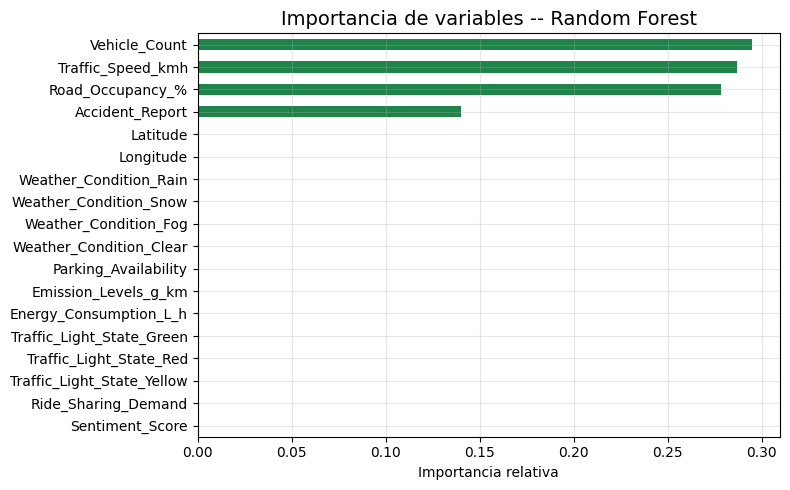

In [40]:
importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importancias.plot(kind="barh", color="#1E8449", ax=ax)
ax.set_title("Importancia de variables -- Random Forest", fontsize=14)
ax.set_xlabel("Importancia relativa")
plt.tight_layout()
plt.show()

Las variables con mayor importancia son las que mas contribuyen a reducir el error en las predicciones. Esto nos da una idea clara de cuales variables son las mas relevantes para predecir el precio.

---

## 7. XGBoost para regresion

XGBoost (eXtreme Gradient Boosting) es otro modelo basado en arboles, pero con una filosofia diferente a Random Forest:

- **Random Forest**: entrena muchos arboles en paralelo con muestras distintas y promedia.
- **XGBoost**: entrena arboles en secuencia, donde cada arbol nuevo intenta **corregir los errores del anterior**.

Esta estrategia (llamada "boosting") suele dar resultados muy precisos. Es el modelo que mas se usa en competencias de machine learning y en muchas aplicaciones industriales.

XGBoost tambien incluye **regularizacion interna**, lo cual ayuda a controlar el overfitting.

In [31]:
xgb_model = xgb.XGBRegressor(
    n_estimators=200,       # numero de arboles
    max_depth=6,            # profundidad maxima
    learning_rate=0.1,      # tasa de aprendizaje (que tan rapido aprende)
    subsample=0.8,          # fraccion de datos para cada arbol
    colsample_bytree=0.8,   # fraccion de variables para cada arbol
    reg_alpha=0.1,          # regularizacion L1 (tipo Lasso)
    reg_lambda=1.0,         # regularizacion L2 (tipo Ridge)
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)  # Tampoco necesita escalamiento
y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

pd.DataFrame({
    "Metrica": ["MAE", "RMSE", "R2"],
    "Valor": [round(mae_xgb, 4), round(rmse_xgb, 4), round(r2_xgb, 4)]
})

,Metrica,Valor
0,MAE,0.0306
1,RMSE,0.0517
2,R2,0.9927


Nota sobre los hiperparametros de XGBoost:

- `n_estimators`: cuantos arboles construir. Mas arboles = mas capacidad, pero tambien mas tiempo.
- `max_depth`: que tan "profundos" pueden ser los arboles. Arboles mas profundos capturan patrones mas complejos pero pueden sobreajustar.
- `learning_rate`: controla cuanto "aprende" cada arbol nuevo. Valores pequenos requieren mas arboles pero suelen generalizar mejor.
- `subsample` y `colsample_bytree`: fraccion de datos y variables usadas por cada arbol. Valores menores a 1.0 agregan aleatoriedad que ayuda a evitar overfitting.
- `reg_alpha` y `reg_lambda`: regularizacion L1 y L2 integrada en el modelo.

---

## 9. Comparacion final de todos los modelos

Veamos todos los modelos que hemos entrenado, lado a lado:

In [53]:
comparacion = pd.DataFrame({
    "Modelo": [
        "Regresion Lineal (OLS)",
        "Ridge (mejor alpha por CV)",
        "Lasso (mejor alpha por CV)",
        "Elastic Net (CV)",
        "Ridge + Polinomicos",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        round(mae_lr, 4),
        round(mean_absolute_error(y_test, ridge_cv.predict(X_test_sc)), 4),
        round(mean_absolute_error(y_test, lasso_cv.predict(X_test_sc)), 4),
        round(mean_absolute_error(y_test, en_cv.predict(X_test_sc)), 4),
        round(mean_absolute_error(y_test, y_pred_ridge_poly), 4),
        round(mae_rf, 4),
        round(mae_xgb, 4),
    ],
    "RMSE": [
        round(rmse_lr, 4),
        round(np.sqrt(mean_squared_error(y_test, ridge_cv.predict(X_test_sc))), 4),
        round(np.sqrt(mean_squared_error(y_test, lasso_cv.predict(X_test_sc))), 4),
        round(np.sqrt(mean_squared_error(y_test, en_cv.predict(X_test_sc))), 4),
        round(np.sqrt(mean_squared_error(y_test, y_pred_ridge_poly)), 4),
        round(rmse_rf, 4),
        round(rmse_xgb, 4),
    ],
    "R2": [
        round(r2_lr, 4),
        round(r2_score(y_test, ridge_cv.predict(X_test_sc)), 4),
        round(r2_score(y_test, lasso_cv.predict(X_test_sc)), 4),
        round(r2_score(y_test, en_cv.predict(X_test_sc)), 4),
        round(r2_score(y_test, y_pred_ridge_poly), 4),
        round(r2_rf, 4),
        round(r2_xgb, 4),
    ]
})

comparacion.sort_values("R2", ascending=False)

NameError: name 'y_pred_ridge_poly' is not defined

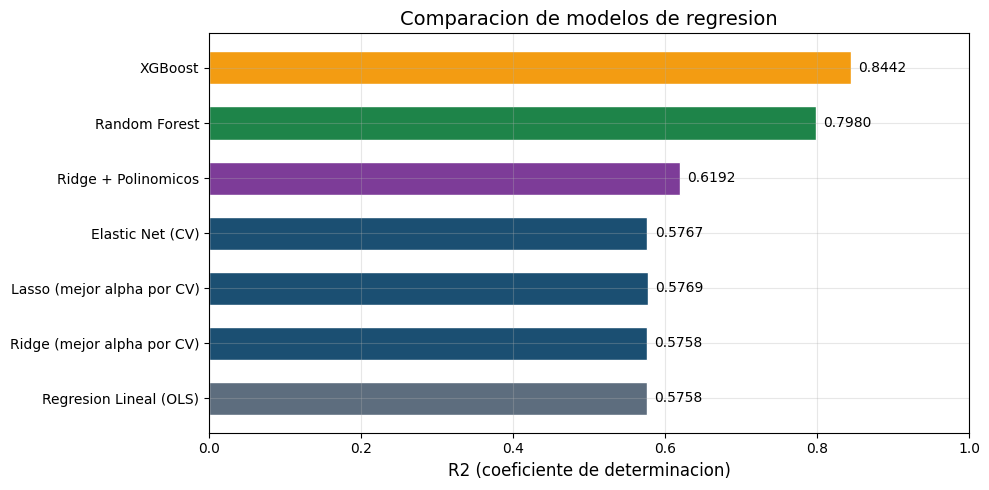

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

modelos = comparacion["Modelo"]
r2_vals = comparacion["R2"]
colores = ["#5D6D7E", "#1B4F72", "#1B4F72", "#1B4F72", "#7D3C98", "#1E8449", "#F39C12"]

bars = ax.barh(modelos, r2_vals, color=colores, edgecolor="white", height=0.6)
ax.set_xlabel("R2 (coeficiente de determinacion)", fontsize=12)
ax.set_title("Comparacion de modelos de regresion", fontsize=14)
ax.set_xlim(0, 1)

for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

## 10. Conclusiones

Recapitulando lo que hemos aprendido:

1. **Regularizacion** (Ridge, Lasso, Elastic Net) es una mejora directa sobre la regresion lineal clasica. Controla el overfitting y, en el caso de Lasso, tambien selecciona variables. Siempre requiere estandarizar las variables primero.

2. **Random Forest y XGBoost** son modelos basados en arboles que capturan relaciones no lineales sin necesidad de especificarlas manualmente. No requieren escalamiento de variables. Suelen dar mejor desempeno que los modelos lineales en datasets complejos.

3. **Feature Engineering** (transformaciones, interacciones, variables polinomicas) puede mejorar significativamente cualquier modelo. Es donde la creatividad y el conocimiento del dominio marcan la diferencia.

4. **Seleccion de variables** nos permite construir modelos mas simples, rapidos e interpretables. Los tres metodos principales son: importancia en Random Forest, coeficientes de Lasso, y eliminacion recursiva (RFE).

5. **Siempre comparar multiples modelos** y evaluar con validacion cruzada antes de elegir el modelo final.

---

**Siguiente paso**: en el notebook de practica, aplica estos conceptos a un dataset diferente y experimenta con distintas combinaciones de modelos y features.